In [1]:
import subprocess
from ultralytics import YOLO
from pathlib import Path

In [ ]:


# Dataset slug and output directory
DATASET = "vencerlanz09/taco-dataset-yolo-format"
OUT_DIR = Path("taco_dataset")

def download_dataset():
    """Download and unzip dataset using kaggle CLI."""
    if not OUT_DIR.exists():
        OUT_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "kaggle", "datasets", "download",
        "-d", DATASET,
        "-p", str(OUT_DIR),
        "--unzip"
    ], check=True)

download_dataset()


In [ ]:
OUT_DIR = Path("taco_dataset")
def train():
    """Train YOLO11n model on the dataset's data.yaml."""
    data_yaml = next(OUT_DIR.rglob("data.yaml"))  # find data.yaml inside dataset
    model = YOLO("yolo11n.pt")  # load YOLO11n
    model.train(data=str(data_yaml), epochs=100, imgsz=640, batch=32)
    
train()

In [ ]:
# Load the trained model
model = YOLO("runs/detect/train2/weights/best.pt")  # or last.pt, or any epochX.pt

# Predict on a single image
results = model("capture.jpg")

# Show the predictions
results[0].show()

# Save the predictions to disk
#results.save("runs/predict/")

In [ ]:
model = YOLO("runs/detect/train2/weights/best.pt")

# Export to TensorFlow Lite
model.export(format="tflite")

In [10]:
model = YOLO("runs/detect/train2/weights/best.pt")

model.export(format="openvivo")

WARNING ⚠️ Invalid export format='openvivo', updating to format='openvino'
Ultralytics 8.3.203 🚀 Python-3.12.3 torch-2.8.0+cu128 CPU (AMD Ryzen AI 9 HX 370 w/ Radeon 890M)
YOLO11n summary (fused): 100 layers, 2,585,662 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'runs/detect/train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 22, 8400) (5.2 MB)
requirements: Ultralytics requirement ['openvino>=2024.0.0'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/49.0 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/49.0 MB 192.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/49.0 MB 192.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/49.0 MB 731.3 kB/s eta 0:01:07
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/49.0 MB 731.3 kB/s eta 0:01:07
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/49.0 MB 731.3 kB/s eta 0:01:07
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

'runs/detect/train2/weights/best_openvino_model'

In [ ]:
from ultralytics import YOLO
import torch
import numpy as np
import random

# 1. Fix seeds
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# 2. Load the model
model = YOLO("runs/detect/train2/weights/best.pt")

# 3. Set to evaluation mode
model.model.eval()

# 4. Export to NCNN
model.export(format="ncnn", verbose=True)


Loading runs/detect/train2/weights/best_openvino_model/ for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

image 1/1 /home/no0byeby/projects/trashDetecttion/WhatsApp Image 2025-09-14 at 22.46.01.jpeg: 640x640 1 Bottle cap, 1 Can, 31.8ms
Speed: 2.3ms preprocess, 31.8ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)


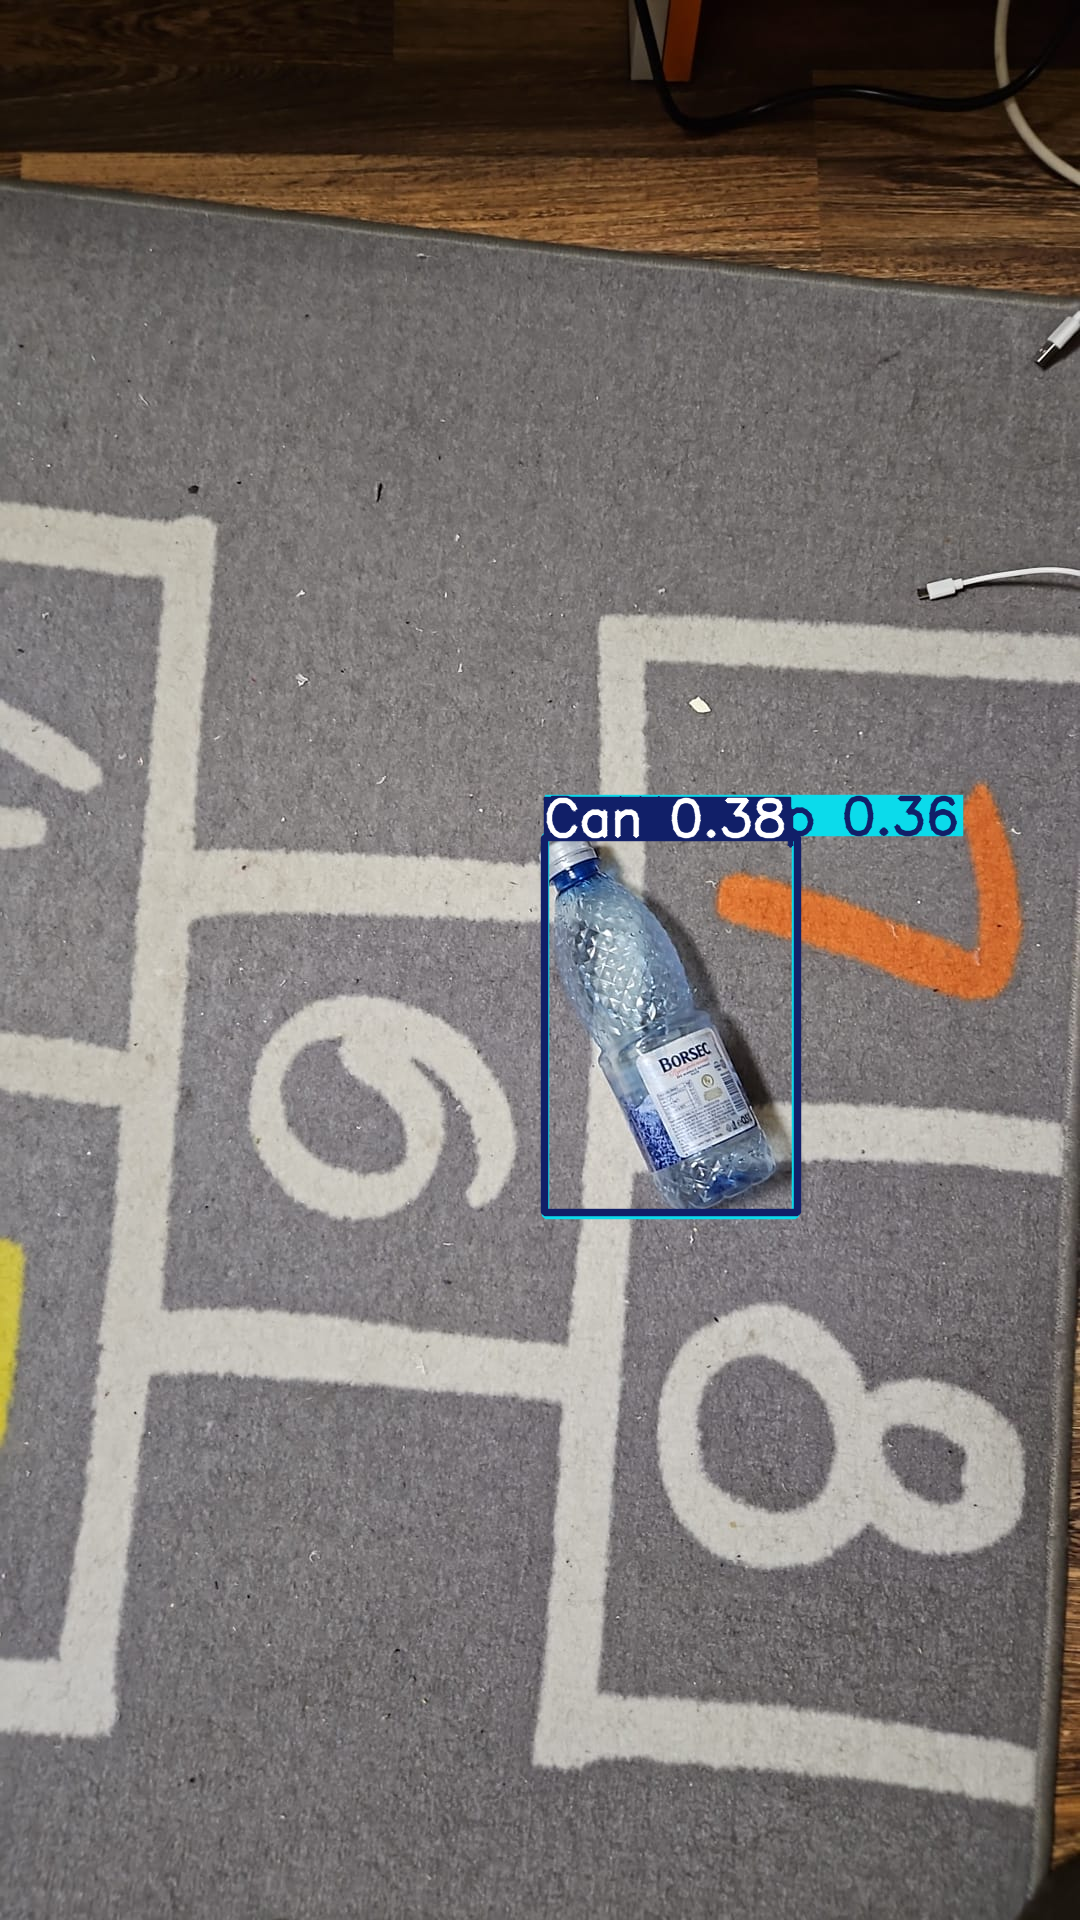

tensor([[5.4450e+02, 8.3700e+02, 7.9725e+02, 1.2128e+03, 3.7984e-01, 4.0000e+00],
        [5.4544e+02, 8.3512e+02, 7.9500e+02, 1.2150e+03, 3.6207e-01, 1.0000e+00]])

In [31]:
# Load the trained model
model = YOLO("runs/detect/train2/weights/best_openvino_model/")

# Predict on a single image
results = model.predict("WhatsApp Image 2025-09-14 at 22.46.01.jpeg")

# Show the predictions
results[0].show()

results[0].boxes.data

# Save the predictions to disk
#results.save("runs/predict/")